# Explore GSE123813 BCC T-cell Dataset (Yost et al. 2019)

**Dataset**: Yost et al. 2019 — T cells from BCC (basal cell carcinoma) patients,  
single-cell RNA-seq + TCR-seq, pre- and post-anti-PD1 immunotherapy.

**Key question**: Are these tumor-reactive T cells?  
Short answer: unlike Caushi 2021, Yost 2019 does **not** have a direct  
tumor-reactivity assay. Instead, exhaustion state (`CD8_ex`, `CD8_ex_act`)  
and clonal expansion are used as **proxies** for tumor reactivity.

| Column | Meaning |
|--------|---------|
| `cluster` | Original Yost 2019 cell-type annotation (9 types) |
| `clonotype_id` | TCR CDR3 amino acid sequence (NA if no TCR detected) |
| `has_tcr` | Boolean — TCR detected |
| `treatment` | `pre` or `post` anti-PD1 |
| `patient` | 11 patients: su001–su012 (no su011) |


In [1]:
suppressPackageStartupMessages({
  .libPaths(c("renv/library/macos/R-4.4/aarch64-apple-darwin20", .libPaths()))
  library(Seurat)
  library(ggplot2)
  library(dplyr)
  library(tidyr)
})

options(repr.plot.width = 10, repr.plot.height = 4.5)

# Load all per-patient query objects to get the full dataset
patients <- c("su001","su002","su003","su004","su005",
              "su006","su007","su008","su009","su010","su012")
all_meta <- lapply(patients, function(pt) {
  obj <- readRDS(paste0("data/cca/query_", pt, ".rds"))
  obj@meta.data$cell_id <- colnames(obj)
  obj@meta.data
})
meta <- do.call(rbind, all_meta)
rownames(meta) <- NULL

cat("Total cells:", nrow(meta), "\n")
cat("Patients:", length(unique(meta$patient)), "\n")
cat("Columns:", paste(colnames(meta), collapse=", "), "\n")


Total cells: 30634 


Patients: 11 


Columns: orig.ident, nCount_RNA, nFeature_RNA, patient, treatment, cluster, UMAP1, UMAP2, clonotype_id, has_tcr, percent.mt, RNA_snn_res.0.5, seurat_clusters, doublet_score, predicted_doublet, cell_id 


## 1. Dataset Overview

In [2]:
cat("=== Cell-type distribution ===\n")
ct <- sort(table(meta$cluster), decreasing=TRUE)
print(ct)
cat("\n=== Treatment ===\n")
print(table(meta$treatment))
cat("\n=== TCR detection ===\n")
print(table(meta$has_tcr))
cat("  TCR detection rate:", round(100*mean(meta$has_tcr), 1), "%\n")
cat("\n=== Cells per patient ===\n")
print(sort(table(meta$patient), decreasing=TRUE))


=== Cell-type distribution ===



      Th17    CD8_mem      Naive      Tregs    CD8_act        Tfh     CD8_ex 
      7388       5753       4861       4180       3641       2622       1174 
   CD8_eff CD8_ex_act 
       734        281 



=== Treatment ===



 post   pre 
17511 13123 



=== TCR detection ===



FALSE  TRUE 
 5642 24992 


  TCR detection rate: 81.6 %



=== Cells per patient ===



su009 su001 su008 su006 su012 su005 su007 su004 su010 su002 su003 
 8490  4616  4541  3500  3097  2944  1582   815   587   255   207 


## 2. Cell-type Bar Chart

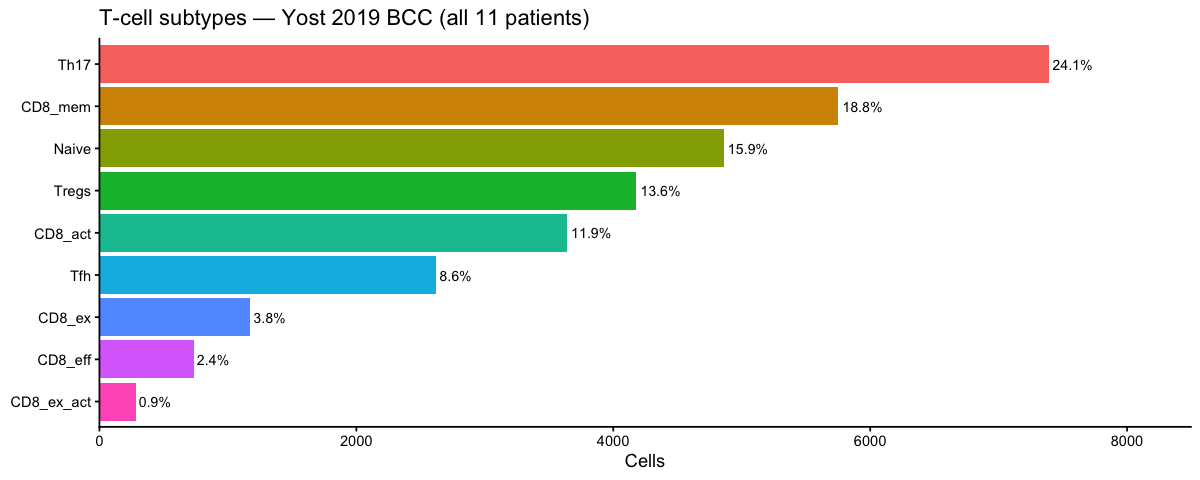

In [3]:
options(repr.plot.width = 10, repr.plot.height = 4)
ct_df <- as.data.frame(ct)
ct_df$pct <- round(100 * ct_df$Freq / sum(ct_df$Freq), 1)

p <- ggplot(ct_df, aes(x = reorder(Var1, Freq), y = Freq, fill = Var1)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  geom_text(aes(label = paste0(pct, "%")), hjust = -0.1, size = 3) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  labs(title = "T-cell subtypes — Yost 2019 BCC (all 11 patients)",
       x = NULL, y = "Cells") +
  theme_classic(base_size = 11)
print(p)


## 3. UMAP — All Cells

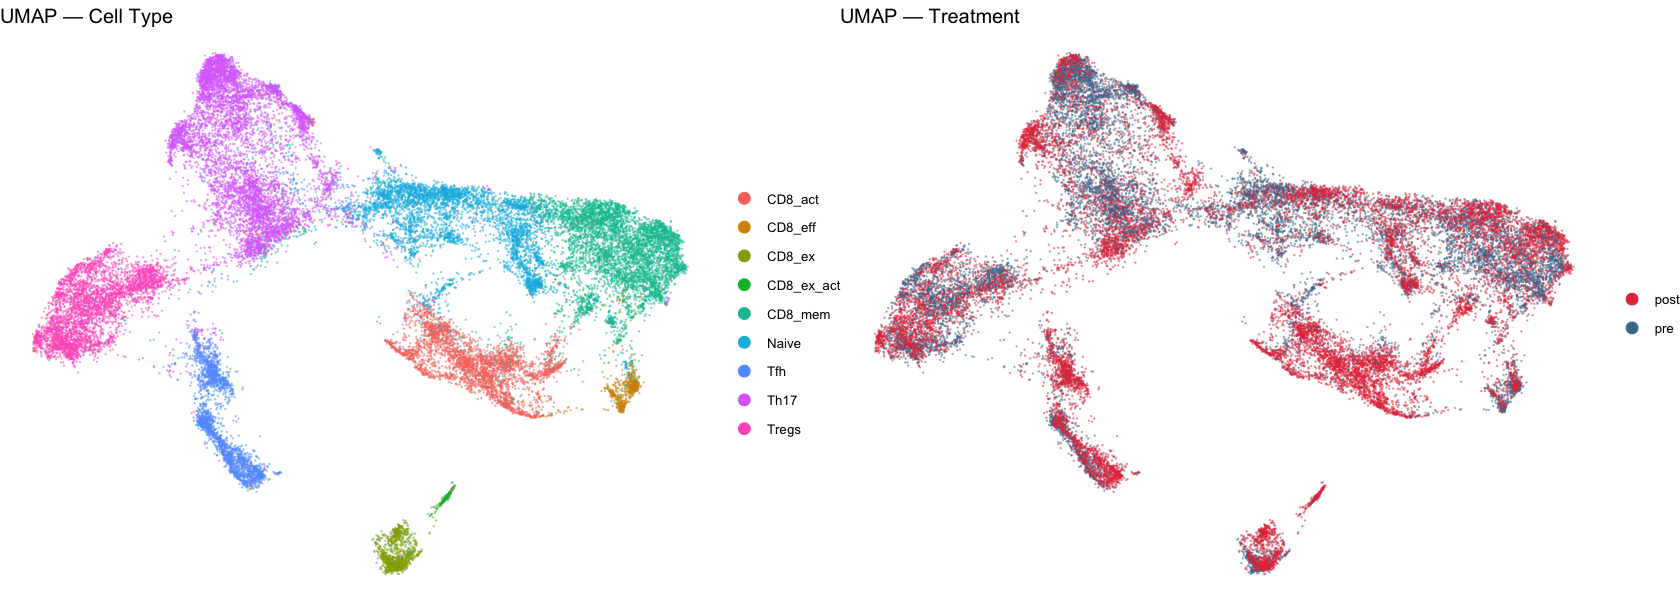

In [4]:
options(repr.plot.width = 14, repr.plot.height = 5)

p1 <- ggplot(meta, aes(UMAP1, UMAP2, colour = cluster)) +
  geom_point(size = 0.1, alpha = 0.4) +
  theme_void(base_size = 10) +
  guides(colour = guide_legend(override.aes = list(size=3, alpha=1))) +
  labs(title = "UMAP — Cell Type", colour = NULL)

p2 <- ggplot(meta, aes(UMAP1, UMAP2, colour = treatment)) +
  geom_point(size = 0.1, alpha = 0.4) +
  scale_colour_manual(values = c("pre"="#457b9d","post"="#e63946")) +
  theme_void(base_size = 10) +
  guides(colour = guide_legend(override.aes = list(size=3, alpha=1))) +
  labs(title = "UMAP — Treatment", colour = NULL)

gridExtra::grid.arrange(p1, p2, ncol = 2)


## 4. Are These Tumor-reactive? — Exhaustion as a Proxy

In [5]:
cat("=== Key distinction from Caushi 2021 ===\n")
cat("\n")
cat("Yost 2019 does NOT have a direct tumor-reactivity assay.\n")
cat("Tumor-reactive T cells are inferred from:\n")
cat("  1) Cell state: CD8_ex (exhausted) and CD8_ex_act (exhausted+activated)\n")
cat("     are the strongest proxies — exhaustion is driven by chronic antigen\n")
cat("     stimulation from tumor neoantigens.\n")
cat("  2) Clonal expansion: tumor-reactive clones tend to be large.\n")
cat("  3) Pre→post treatment dynamics: anti-PD1 reinvigorates CD8_ex cells.\n\n")

# Exhaustion category
meta$is_exhausted <- meta$cluster %in% c("CD8_ex", "CD8_ex_act")
cat("Exhausted cells (CD8_ex + CD8_ex_act):\n")
print(table(meta$is_exhausted))
cat("Exhaustion rate:", round(100*mean(meta$is_exhausted), 1), "%\n")


=== Key distinction from Caushi 2021 ===


Yost 2019 does NOT have a direct tumor-reactivity assay.


Tumor-reactive T cells are inferred from:


  1) Cell state: CD8_ex (exhausted) and CD8_ex_act (exhausted+activated)


     are the strongest proxies — exhaustion is driven by chronic antigen


...

  2) Clonal expansion: tumor-reactive clones tend to be large.


  3) Pre→post treatment dynamics: anti-PD1 reinvigorates CD8_ex cells.



Exhausted cells (CD8_ex + CD8_ex_act):



FALSE  TRUE 
29179  1455 


Exhaustion rate: 4.7 %


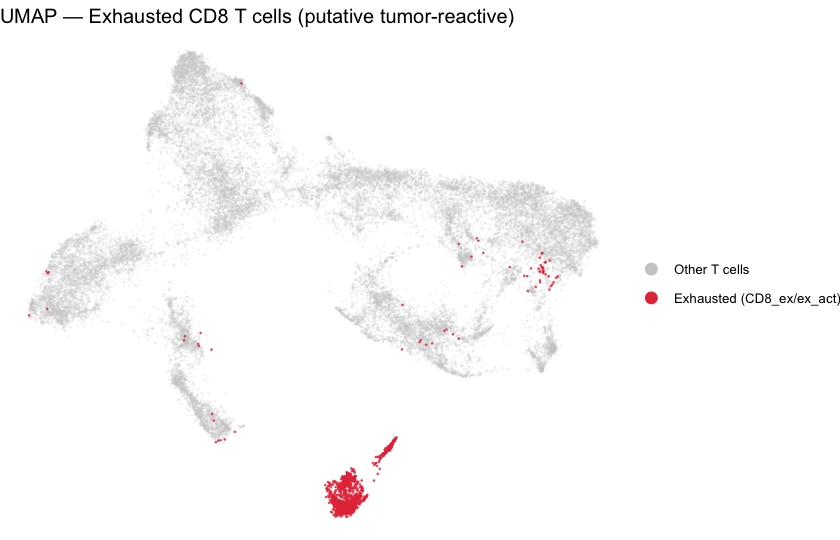

In [6]:
options(repr.plot.width = 7, repr.plot.height = 4.5)

p_ex <- ggplot(meta %>% arrange(is_exhausted),
               aes(UMAP1, UMAP2,
                   colour = is_exhausted,
                   alpha  = is_exhausted)) +
  geom_point(size = 0.15) +
  scale_colour_manual(values = c("FALSE"="grey80", "TRUE"="#e63946"),
                      labels = c("Other T cells", "Exhausted (CD8_ex/ex_act)")) +
  scale_alpha_manual(values = c("FALSE"=0.15, "TRUE"=0.7), guide="none") +
  theme_void(base_size=10) +
  guides(colour=guide_legend(override.aes=list(size=3, alpha=1))) +
  labs(title="UMAP — Exhausted CD8 T cells (putative tumor-reactive)", colour=NULL)
print(p_ex)


## 5. Clonal Expansion

In [7]:
# Clonotype sizes
clo_size <- meta %>%
  filter(!is.na(clonotype_id)) %>%
  count(clonotype_id, cluster, name="clone_size") %>%
  arrange(desc(clone_size))

cat("=== Top 20 clonotypes by size ===\n")
print(head(clo_size, 20))

cat("\n=== Clonotype size distribution ===\n")
cat("Unique clonotypes:", length(unique(na.omit(meta$clonotype_id))), "\n")
cat("Cells with TCR:", sum(!is.na(meta$clonotype_id)), "\n")


=== Top 20 clonotypes by size ===


        clonotype_id cluster clone_size
1      CATKGYQAGELFF  CD8_ex        351
2   CASSLAGTSPSNEQFF   Naive        126
3   CASSIDWTGYLDTQYF CD8_mem         98
4     CASSLNPGADTQYF CD8_mem         91
5   CASSGEVTGGPYEQYF   Naive         88
6    CASSTGLEKYNEQFF    Th17         78
7    CASSQTSGIYNEQFF CD8_mem         74
8  CASSQEGQSSYNSPLHF CD8_mem         73
9  CASSYAPQGRIVETQYF    Th17         71
10    CASSPTGGGQGYTF   Naive         70
11    CASSVYPHTDTQYF   Naive         69
12 CASSLVVADPYQETQYF CD8_act         57
13  CASTSDRNFYNSPLHF   Naive         56
14   CASSQEGSSGYEQYF  CD8_ex         54
15  CATSDLGQGVGNEQFF CD8_mem         54
16  CASSIDWTGYLQPQHF CD8_act         53
17    CASSVYPSTDTQYF   Naive         52
18    CASSFGQEPFTLHF CD8_mem         51
19    CSARDRARSTEAFF CD8_act         48
20  CASSLLGRGTTDTQYF CD8_act         47



=== Clonotype size distribution ===


Unique clonotypes: 12847 


Cells with TCR: 24992 


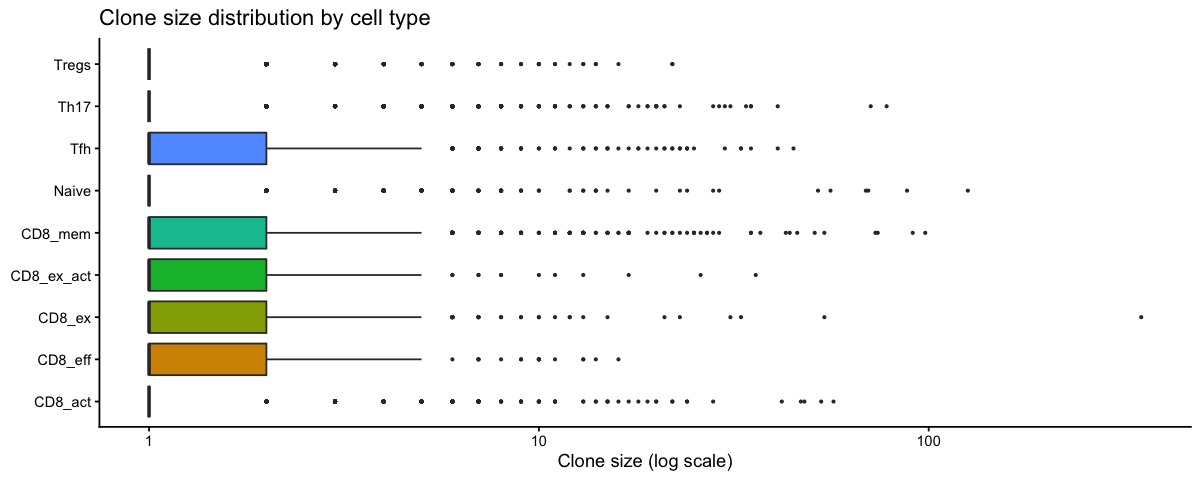

In [8]:
options(repr.plot.width = 10, repr.plot.height = 4)

# Clone size by cell type (how large are exhausted clones?)
clone_ct <- meta %>%
  filter(!is.na(clonotype_id)) %>%
  group_by(clonotype_id, cluster) %>%
  summarise(n=n(), .groups="drop")

p_box <- ggplot(clone_ct, aes(x = reorder(cluster, n, median),
                               y = n, fill = cluster)) +
  geom_boxplot(show.legend=FALSE, outlier.size=0.5) +
  coord_flip() +
  scale_y_log10() +
  labs(title="Clone size distribution by cell type",
       x=NULL, y="Clone size (log scale)") +
  theme_classic(base_size=11)
print(p_box)


## 6. Pre vs Post Treatment — Exhaustion Shift


=== Exhausted % by treatment ===


# A tibble: 2 × 2
  treatment pct_exhausted
  <chr>             <dbl>
1 post                6.2
2 pre                 2.8


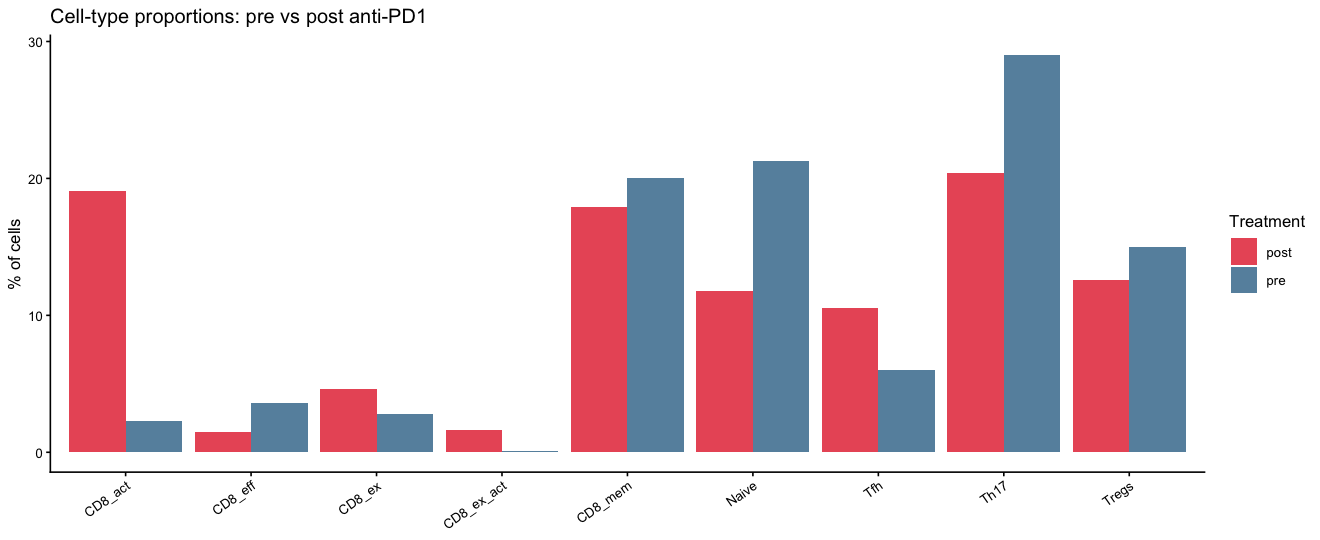

In [9]:
options(repr.plot.width = 11, repr.plot.height = 4.5)

treat_ct <- meta %>%
  group_by(treatment, cluster) %>%
  summarise(n=n(), .groups="drop") %>%
  group_by(treatment) %>%
  mutate(pct=round(100*n/sum(n),1))

p_treat <- ggplot(treat_ct, aes(x=cluster, y=pct, fill=treatment)) +
  geom_col(position="dodge", alpha=0.85) +
  scale_fill_manual(values=c("pre"="#457b9d","post"="#e63946")) +
  labs(title="Cell-type proportions: pre vs post anti-PD1",
       x=NULL, y="% of cells", fill="Treatment") +
  theme_classic(base_size=10) +
  theme(axis.text.x=element_text(angle=35, hjust=1))
print(p_treat)

cat("\n=== Exhausted % by treatment ===\n")
meta %>%
  group_by(treatment) %>%
  summarise(pct_exhausted=round(100*mean(is_exhausted),1)) %>%
  print()


## 7. Per-patient Exhaustion

# A tibble: 22 × 5
   patient treatment n_total  n_ex pct_ex
   <chr>   <chr>       <int> <int>  <dbl>
 1 su001   post         3663   328    9  
 2 su001   pre           953     9    0.9
 3 su002   post          170    30   17.6
 4 su002   pre            85     0    0  
 5 su003   post          115     1    0.9
 6 su003   pre            92     0    0  
 7 su004   post          284     6    2.1
 8 su004   pre           531     0    0  
 9 su005   post         1916     2    0.1
10 su005   pre          1028     3    0.3
# ℹ 12 more rows


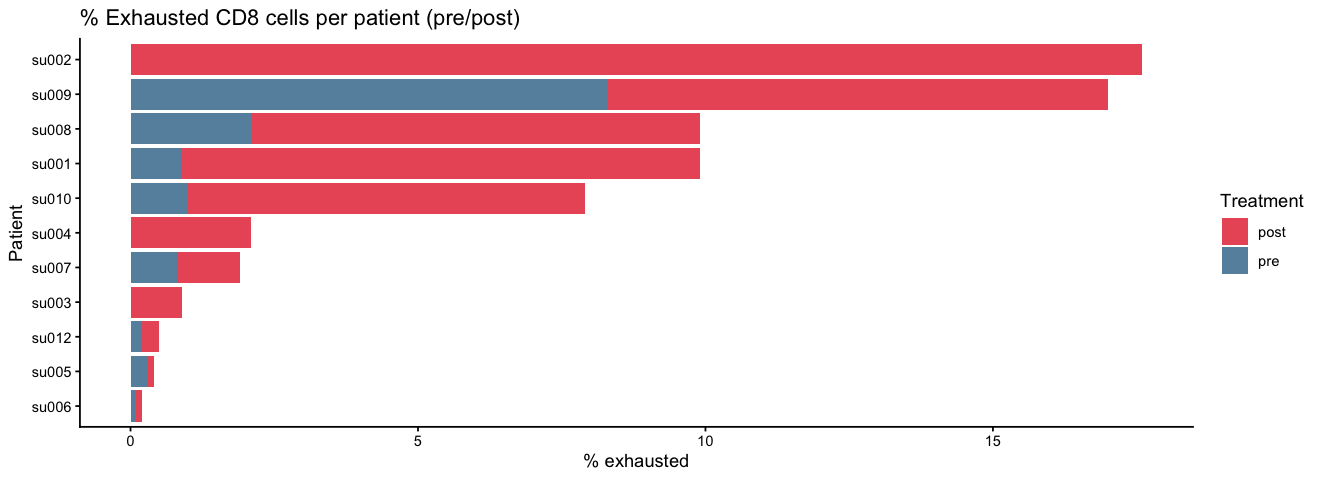

In [10]:
options(repr.plot.width = 11, repr.plot.height = 4)

pat_ex <- meta %>%
  group_by(patient, treatment) %>%
  summarise(n_total=n(),
            n_ex=sum(is_exhausted),
            pct_ex=round(100*mean(is_exhausted),1),
            .groups="drop")
print(pat_ex)

p_pat <- ggplot(pat_ex, aes(x=reorder(patient, pct_ex), y=pct_ex, fill=treatment)) +
  geom_col(alpha=0.85) +
  coord_flip() +
  scale_fill_manual(values=c("pre"="#457b9d","post"="#e63946")) +
  labs(title="% Exhausted CD8 cells per patient (pre/post)",
       x="Patient", y="% exhausted", fill="Treatment") +
  theme_classic(base_size=11)
print(p_pat)


## 8. TCR Overlap with Caushi 2021 (Clonotype Matching)

In [11]:
# Load the Caushi clonotype summary built by the pipeline
caushi_clo <- read.csv("data/caushi2021_ranked_clonotypes.csv", stringsAsFactors=FALSE)

cat("=== Caushi 2021 reactive clonotypes ===\n")
print(caushi_clo[, c("clonotype_id","clone_size","is_tumor_reactive","patient")])

cat("\nNote: Caushi clonotypes are patient-level identifiers (imid = clonotype_id).\n")
cat("Direct CDR3 sequence overlap between datasets was used in notebook 04\n")
cat("to transfer tumor-reactivity labels from Caushi 2021 to Yost 2019 clones.\n")

# Check if any Yost clonotypes overlap with Caushi CDR3s
yost_clonotypes <- unique(na.omit(meta$clonotype_id))
cat("\nYost 2019 unique clonotypes:", length(yost_clonotypes), "\n")
# Note: actual CDR3 matching is in 04_tcr_reactivity_selection.ipynb


=== Caushi 2021 reactive clonotypes ===


   clonotype_id clone_size is_tumor_reactive   patient
1      MD01-004      15092              TRUE  MD01-004
2      MD01-005      41005              TRUE  MD01-005
3      MD01-010       2799              TRUE  MD01-010
4      MD01-019      14408              TRUE  MD01-019
5      MD01-024        821              TRUE  MD01-024
6     MD043-003      24988              TRUE MD043-003
7     MD043-006      11248              TRUE MD043-006
8     MD043-008       2858              TRUE MD043-008
9     MD043-011      44275              TRUE MD043-011
10    NY016-007       5409              TRUE NY016-007
11    NY016-014       9276              TRUE NY016-014
12    NY016-015       6498              TRUE NY016-015
13    NY016-016       1389              TRUE NY016-016
14    NY016-021        777              TRUE NY016-021
15    NY016-022      24246              TRUE NY016-022
16    NY016-025      28160              TRUE NY016-025
17         <NA>       2602              TRUE      <NA>



Note: Caushi clonotypes are patient-level identifiers (imid = clonotype_id).


Direct CDR3 sequence overlap between datasets was used in notebook 04


to transfer tumor-reactivity labels from Caushi 2021 to Yost 2019 clones.



Yost 2019 unique clonotypes: 12847 


## 9. Summary

In [12]:
cat("╔══════════════════════════════════════════════════════════╗\n")
cat("║  GSE123813 BCC T-cell dataset — key facts               ║\n")
cat("╚══════════════════════════════════════════════════════════╝\n\n")

cat("Dataset: Yost et al. 2019 (BCC, anti-PD1)\n")
cat("  Total T cells :", nrow(meta), "\n")
cat("  Patients       :", length(unique(meta$patient)), "\n")
cat("  Cell types     :", length(unique(meta$cluster)), "\n")
cat("  Treatment      : pre=", sum(meta$treatment=="pre"),
    " post=", sum(meta$treatment=="post"), "\n\n")

cat("TCR repertoire:\n")
cat("  Cells with TCR  :", sum(!is.na(meta$clonotype_id)), "\n")
cat("  Unique clones   :", length(unique(na.omit(meta$clonotype_id))), "\n\n")

cat("Tumor reactivity:\n")
cat("  → NO direct reactivity assay (unlike Caushi 2021)\n")
cat("  → CD8_ex + CD8_ex_act =", sum(meta$is_exhausted), "cells (",
    round(100*mean(meta$is_exhausted),1), "%) are PROXIES for tumor-reactive CD8\n")
cat("  → Pipeline uses clonotype overlap with Caushi 2021 CDR3 sequences\n")
cat("    to infer which Yost clonotypes match known tumor-reactive TCRs\n")


╔══════════════════════════════════════════════════════════╗


║  GSE123813 BCC T-cell dataset — key facts               ║


╚══════════════════════════════════════════════════════════╝



Dataset: Yost et al. 2019 (BCC, anti-PD1)


  Total T cells : 30634 


...

Tumor reactivity:


  → NO direct reactivity assay (unlike Caushi 2021)


  → CD8_ex + CD8_ex_act = 1455 cells ( 4.7 %) are PROXIES for tumor-reactive CD8


  → Pipeline uses clonotype overlap with Caushi 2021 CDR3 sequences


    to infer which Yost clonotypes match known tumor-reactive TCRs
